In [2]:
import os
# Pytorch
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
from torch.utils.data import DataLoader
from torchinfo import summary
# Helper libraries
import numpy as np
import matplotlib.pyplot as plt


In [4]:
base_path = os.path.join(os.getcwd(), '..', '..', 'work')
data_path = os.path.join(base_path, 'data')

In [5]:
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))
])
trainset = torchvision.datasets.CIFAR10(root=data_path, train=True, download=True, transform=transform)
testset = torchvision.datasets.CIFAR10(root=data_path, train=False, download=True, transform=transform)

trainloader = torch.utils.data.DataLoader(trainset, batch_size=32, shuffle=True)
testloader = torch.utils.data.DataLoader(testset, batch_size=32, shuffle=False)

100%|██████████| 170M/170M [00:21<00:00, 7.83MB/s] 


In [6]:
# 데이터셋을 로드하고 기본 정보를 확인해 보세요.
image, label = trainset[0]

print(f"Image shape: {image.shape}")
print(f"Label: {label}")
print(f"Number of classes: {len(trainset.classes)}")

Image shape: torch.Size([3, 32, 32])
Label: 6
Number of classes: 10


In [7]:
# 데이터의 개수도 확인해 봅시다.
train_size = torch.tensor(len(trainset))
test_size = torch.tensor(len(testset))

print(f"Train dataset size: {train_size} (Shape: {train_size.shape})")
print(f"Test dataset size: {test_size} (Shape: {test_size.shape})")

Train dataset size: 50000 (Shape: torch.Size([]))
Test dataset size: 10000 (Shape: torch.Size([]))


In [12]:
# Q. 이미지의 표현이 0과 1 사이로 들어오도록 직접 Pytorch 정규화 코드를 작성해봅시다.
transform = transforms.Compose([
    transforms.ToTensor()  # uint8 → float32 변환 + 0~1 정규화
])

In [13]:
num_classes = len(trainset.classes)
print(num_classes)

10


In [14]:
class_names = trainset.classes
print(class_names)

['airplane', 'automobile', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck']


In [16]:
def imshow(img):
    img = img / 2 + 0.5
    npimg = img.numpy()
    return np.transpose(npimg, (1, 2, 0))

def show_multiple_images(dataset, n_images=9):
    dataiter = iter(dataset)
    images, labels = next(dataiter)
    fig, axes = plt.subplots(3, 3, figsize=(6, 6))
    axes = axes.flatten()

    for i in range(n_images):
        ax = axes[i]
        img = imshow(images[i])
        ax.imshow(img)
        ax.set_title(f"Label: {trainset.classes[labels[i]]}")
        ax.axis('off')

    plt.tight_layout()
    plt.show()

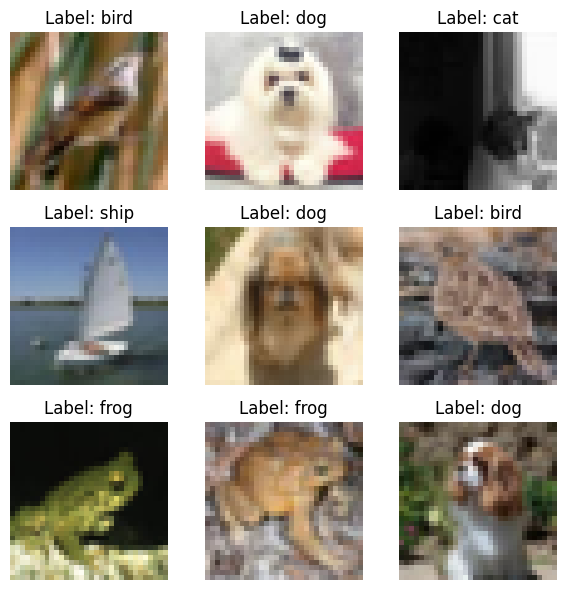

In [17]:
# 학습 데이터셋에서 9개의 이미지를 시각화합니다.
show_multiple_images(trainloader)

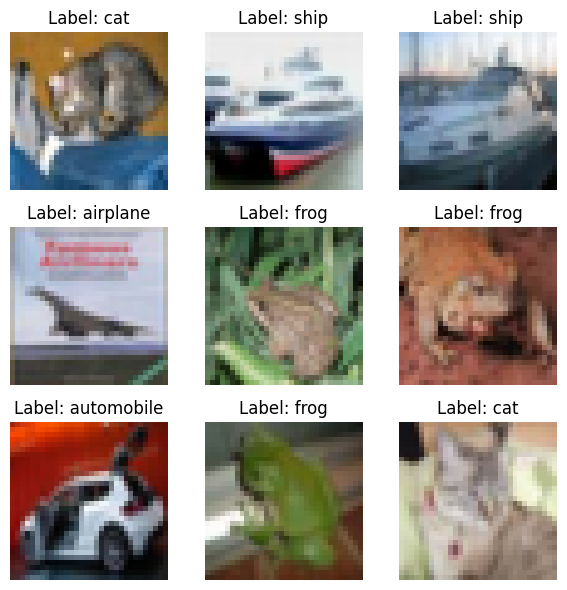

In [18]:
# 테스트 데이터셋에서 9개의 이미지를 시각화합니다.
show_multiple_images(testloader)

In [19]:
# function for building VGG Block

def build_vgg_block(input_layer,
                    num_cnn=3,
                    channel=64,
                    block_num=1):
    # 입력 레이어
    x = input_layer

    # CNN 레이어
    layers = []
    in_channels = x.size(1)
    for cnn_num in range(num_cnn):
        layers.append(
            nn.Conv2d(
                in_channels=in_channels,
                out_channels=channel,
                kernel_size=3,
                stride=1,
                padding=1,
            )
        )
        layers.append(nn.ReLU(inplace=True))
        in_channels = channel

    # Max Pooling 레이어
    layers.append(
        nn.MaxPool2d(
            kernel_size=2,
            stride=2
        )
    )

    # Sequential으로 레이어 묶기
    block = nn.Sequential(*layers)
    return block

In [20]:
class VGGNet(nn.Module):
    def __init__(self):
        super(VGGNet, self).__init__()

        # VGG 블록 생성
        self.vgg_block = build_vgg_block(torch.zeros(1, 3, 32, 32))
    def forward(self, x):
        return self.vgg_block(x)

In [21]:
# VGG 모델 자체를 생성하는 클래스입니다.
class VGG(nn.Module):
    def __init__(self, num_cnn_list=[2, 2, 3, 3, 3], channel_list=[64, 128, 256, 512, 512], num_classes=10):
        super(VGG, self).__init__()
        assert len(num_cnn_list) == len(channel_list), "num_cnn_list와 channel_list의 길이가 일치해야 합니다."

        layers = []
        in_channels = 3

        for num_cnn, out_channels in zip(num_cnn_list, channel_list):
            layers.append(self._make_vgg_block(in_channels, out_channels, num_cnn))
            in_channels = out_channels  # 다음 블록의 입력 채널을 설정

        self.feature_extractor = nn.Sequential(*layers)
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(512 * 1 * 1, 4096),
            nn.ReLU(True),
            nn.Linear(4096, 4096),
            nn.ReLU(True),
            nn.Linear(4096, num_classes)
        )

    def _make_vgg_block(self, in_channels, out_channels, num_cnn):
        layers = [nn.Conv2d(in_channels, out_channels, kernel_size=3, padding=1), nn.ReLU(True)]
        for _ in range(num_cnn - 1):
            layers.append(nn.Conv2d(out_channels, out_channels, kernel_size=3, padding=1))
            layers.append(nn.ReLU(True))
        layers.append(nn.MaxPool2d(kernel_size=2, stride=2))  # Max Pooling 추가
        return nn.Sequential(*layers)

    def forward(self, x):
        x = self.feature_extractor(x)
        x = self.classifier(x)
        return x

In [22]:
# 기본값을 그대로 사용해서 VGG 모델을 만들면 VGG-16이 됩니다.

vgg_16 = VGG()
summary(vgg_16)

Layer (type:depth-idx)                   Param #
VGG                                      --
├─Sequential: 1-1                        --
│    └─Sequential: 2-1                   --
│    │    └─Conv2d: 3-1                  1,792
│    │    └─ReLU: 3-2                    --
│    │    └─Conv2d: 3-3                  36,928
│    │    └─ReLU: 3-4                    --
│    │    └─MaxPool2d: 3-5               --
│    └─Sequential: 2-2                   --
│    │    └─Conv2d: 3-6                  73,856
│    │    └─ReLU: 3-7                    --
│    │    └─Conv2d: 3-8                  147,584
│    │    └─ReLU: 3-9                    --
│    │    └─MaxPool2d: 3-10              --
│    └─Sequential: 2-3                   --
│    │    └─Conv2d: 3-11                 295,168
│    │    └─ReLU: 3-12                   --
│    │    └─Conv2d: 3-13                 590,080
│    │    └─ReLU: 3-14                   --
│    │    └─Conv2d: 3-15                 590,080
│    │    └─ReLU: 3-16                  

In [23]:
# 원하는 블록의 설계에 따라 매개변수로 리스트를 전달해 줍니다.
vgg_19 = VGG(
    num_cnn_list=[2, 2, 4, 4, 4],
    channel_list=[64, 128, 256, 512, 512]
)
summary(vgg_19)

Layer (type:depth-idx)                   Param #
VGG                                      --
├─Sequential: 1-1                        --
│    └─Sequential: 2-1                   --
│    │    └─Conv2d: 3-1                  1,792
│    │    └─ReLU: 3-2                    --
│    │    └─Conv2d: 3-3                  36,928
│    │    └─ReLU: 3-4                    --
│    │    └─MaxPool2d: 3-5               --
│    └─Sequential: 2-2                   --
│    │    └─Conv2d: 3-6                  73,856
│    │    └─ReLU: 3-7                    --
│    │    └─Conv2d: 3-8                  147,584
│    │    └─ReLU: 3-9                    --
│    │    └─MaxPool2d: 3-10              --
│    └─Sequential: 2-3                   --
│    │    └─Conv2d: 3-11                 295,168
│    │    └─ReLU: 3-12                   --
│    │    └─Conv2d: 3-13                 590,080
│    │    └─ReLU: 3-14                   --
│    │    └─Conv2d: 3-15                 590,080
│    │    └─ReLU: 3-16                  

In [24]:
# Q. VGG-16보다 작은 네트워크인 VGG-13을 만들어 보세요.
def build_vgg13(num_classes=10):
    return VGG(
        num_cnn_list=[2, 2, 2, 2, 2],
        channel_list=[64, 128, 256, 512, 512],
        num_classes=num_classes
    )

In [25]:
vgg_13 = build_vgg13()
summary(vgg_13)

Layer (type:depth-idx)                   Param #
VGG                                      --
├─Sequential: 1-1                        --
│    └─Sequential: 2-1                   --
│    │    └─Conv2d: 3-1                  1,792
│    │    └─ReLU: 3-2                    --
│    │    └─Conv2d: 3-3                  36,928
│    │    └─ReLU: 3-4                    --
│    │    └─MaxPool2d: 3-5               --
│    └─Sequential: 2-2                   --
│    │    └─Conv2d: 3-6                  73,856
│    │    └─ReLU: 3-7                    --
│    │    └─Conv2d: 3-8                  147,584
│    │    └─ReLU: 3-9                    --
│    │    └─MaxPool2d: 3-10              --
│    └─Sequential: 2-3                   --
│    │    └─Conv2d: 3-11                 295,168
│    │    └─ReLU: 3-12                   --
│    │    └─Conv2d: 3-13                 590,080
│    │    └─ReLU: 3-14                   --
│    │    └─MaxPool2d: 3-15              --
│    └─Sequential: 2-4                   --
│

In [26]:
BATCH_SIZE = 256
EPOCH = 15

In [27]:
# CIFAR-10 데이터셋에 대해 Normalize와 Tensor 변환을 적용하는 코드
transform = transforms.Compose([
    transforms.ToTensor(),  # 이미지를 Tensor로 변환
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])  # VGG-16 표준 정규화
])

trainset = torchvision.datasets.CIFAR10(root=data_path, train=True, download=True, transform=transform)
testset = torchvision.datasets.CIFAR10(root=data_path, train=False, download=True, transform=transform)

trainloader = DataLoader(trainset, batch_size=BATCH_SIZE, shuffle=True)
testloader = DataLoader(testset, batch_size=BATCH_SIZE, shuffle=False)

In [28]:
import time

current_time = time.time()

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
vgg_16 = torchvision.models.vgg16(pretrained=True)
vgg_16.to(device)

for param in vgg_16.parameters():
    param.requires_grad = True
criterion = nn.CrossEntropyLoss()
optimizer = optim.SGD(vgg_16.parameters(), lr=0.001, momentum=0.9, weight_decay=1e-4)

vgg_16_train_losses = []
vgg_16_val_accuracy = []

for epoch in range(EPOCH):
    vgg_16.train()
    running_loss = 0.0
    correct = 0
    total = 0

    for i, (inputs, labels) in enumerate(trainloader, 0):
        inputs, labels = inputs.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = vgg_16(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item()
        _, predicted = torch.max(outputs, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()

        if i % 100 == 99:
            print(f"[{epoch + 1}, {i + 1:5d}] loss: {running_loss / i + 1:.3f}")
            
    train_loss = running_loss / len(trainloader)
    train_acc = 100 * correct / total
    vgg_16_train_losses.append(train_loss)

    print(f"Epoch {epoch + 1}: Train Accuracy: {train_acc:.2f}%")

    vgg_16.eval()
    correct = 0
    total = 0

    with torch.no_grad():
        for inputs, labels in testloader:
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = vgg_16(inputs)
            _, predicted = torch.max(outputs, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()

    val_acc = 100 * correct / total
    vgg_16_val_accuracy.append(val_acc)

    print(f"Epoch {epoch + 1}: Validation Accuracy: {val_acc:.2f}%")

print("Finished Training")
print(time.time() - current_time)

/home/ysoh1113/workspace/projects/AIFFEL_quest_rs/.venv/lib/python3.11/site-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/home/ysoh1113/workspace/projects/AIFFEL_quest_rs/.venv/lib/python3.11/site-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=VGG16_Weights.IMAGENET1K_V1`. You can also use `weights=VGG16_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Downloading: "https://download.pytorch.org/models/vgg16-397923af.pth" to /home/ysoh1113/.cache/torch/hub/checkpoints/vgg16-397923af.pth


100%|██████████| 528M/528M [00:46<00:00, 11.8MB/s] 


[1,   100] loss: 3.947
Epoch 1: Train Accuracy: 40.10%
Epoch 1: Validation Accuracy: 64.24%
[2,   100] loss: 1.903
Epoch 2: Train Accuracy: 71.61%
Epoch 2: Validation Accuracy: 76.16%
[3,   100] loss: 1.641
Epoch 3: Train Accuracy: 79.23%
Epoch 3: Validation Accuracy: 79.52%
[4,   100] loss: 1.534
Epoch 4: Train Accuracy: 82.59%
Epoch 4: Validation Accuracy: 81.58%
[5,   100] loss: 1.446
Epoch 5: Train Accuracy: 85.28%
Epoch 5: Validation Accuracy: 82.29%
[6,   100] loss: 1.390
Epoch 6: Train Accuracy: 86.87%
Epoch 6: Validation Accuracy: 82.52%
[7,   100] loss: 1.344
Epoch 7: Train Accuracy: 88.57%
Epoch 7: Validation Accuracy: 83.63%
[8,   100] loss: 1.298
Epoch 8: Train Accuracy: 90.15%
Epoch 8: Validation Accuracy: 84.14%
[9,   100] loss: 1.257
Epoch 9: Train Accuracy: 91.59%
Epoch 9: Validation Accuracy: 85.07%
[10,   100] loss: 1.210
Epoch 10: Train Accuracy: 92.94%
Epoch 10: Validation Accuracy: 84.35%
[11,   100] loss: 1.182
Epoch 11: Train Accuracy: 93.83%
Epoch 11: Validation

In [29]:
BATCH_SIZE = 256
EPOCH = 10

current_time = time.time()

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
vgg_19 = torchvision.models.vgg19(pretrained=True)
vgg_19.to(device)

for param in vgg_19.parameters():
    param.requires_grad = True
criterion = nn.CrossEntropyLoss()
optimizer = optim.SGD(vgg_19.parameters(), lr=0.001, momentum=0.9, weight_decay=1e-4)

vgg_19_train_losses = []
vgg_19_val_accuracy = []

for epoch in range(EPOCH):
    vgg_19.train()
    running_loss = 0.0
    correct = 0
    total = 0

    for i, (inputs, labels) in enumerate(trainloader, 0):
        inputs, labels = inputs.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = vgg_19(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item()
        _, predicted = torch.max(outputs, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()

        if i % 100 == 99:
            print(f"[{epoch + 1}, {i + 1:5d}] loss: {running_loss / i + 1:.3f}")

    train_loss = running_loss / len(trainloader)
    vgg_19_train_losses.append(train_loss)

    train_acc = 100 * correct / total
    print(f"Epoch {epoch + 1}: Train Accuracy: {train_acc:.2f}%")

    vgg_19.eval()
    correct = 0
    total = 0

    with torch.no_grad():
        for inputs, labels in testloader:
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = vgg_19(inputs)
            _, predicted = torch.max(outputs, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()

    val_acc = 100 * correct / total
    vgg_19_val_accuracy.append(val_acc)

    print(f"Epoch {epoch + 1}: Validation Accuracy: {val_acc:.2f}%")

print("Finished Training")
print(time.time() - current_time)

/home/ysoh1113/workspace/projects/AIFFEL_quest_rs/.venv/lib/python3.11/site-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/home/ysoh1113/workspace/projects/AIFFEL_quest_rs/.venv/lib/python3.11/site-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=VGG19_Weights.IMAGENET1K_V1`. You can also use `weights=VGG19_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Downloading: "https://download.pytorch.org/models/vgg19-dcbb9e9d.pth" to /home/ysoh1113/.cache/torch/hub/checkpoints/vgg19-dcbb9e9d.pth


100%|██████████| 548M/548M [00:49<00:00, 11.7MB/s] 


[1,   100] loss: 3.753
Epoch 1: Train Accuracy: 39.69%
Epoch 1: Validation Accuracy: 66.64%
[2,   100] loss: 1.881
Epoch 2: Train Accuracy: 72.16%
Epoch 2: Validation Accuracy: 77.80%
[3,   100] loss: 1.619
Epoch 3: Train Accuracy: 80.12%
Epoch 3: Validation Accuracy: 80.79%
[4,   100] loss: 1.517
Epoch 4: Train Accuracy: 83.03%
Epoch 4: Validation Accuracy: 82.80%
[5,   100] loss: 1.434
Epoch 5: Train Accuracy: 85.61%
Epoch 5: Validation Accuracy: 83.26%
[6,   100] loss: 1.389
Epoch 6: Train Accuracy: 87.30%
Epoch 6: Validation Accuracy: 83.73%
[7,   100] loss: 1.325
Epoch 7: Train Accuracy: 89.02%
Epoch 7: Validation Accuracy: 85.01%
[8,   100] loss: 1.296
Epoch 8: Train Accuracy: 90.42%
Epoch 8: Validation Accuracy: 85.16%
[9,   100] loss: 1.254
Epoch 9: Train Accuracy: 91.56%
Epoch 9: Validation Accuracy: 85.21%
[10,   100] loss: 1.211
Epoch 10: Train Accuracy: 92.76%
Epoch 10: Validation Accuracy: 85.71%
Finished Training
589.5164802074432


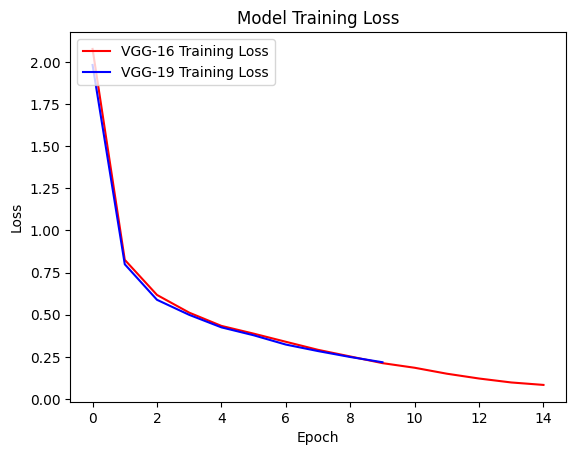

In [30]:
import matplotlib.pyplot as plt

plt.plot(vgg_16_train_losses, 'r', label="VGG-16 Training Loss")
plt.plot(vgg_19_train_losses, 'b', label="VGG-19 Training Loss")

plt.title('Model Training Loss')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend(loc='upper left')
plt.show()

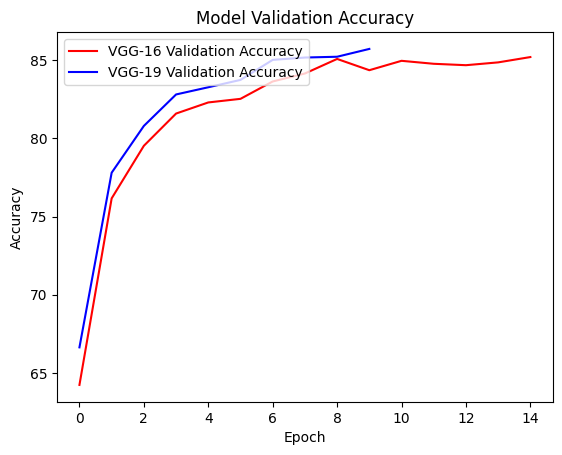

In [31]:
plt.plot(vgg_16_val_accuracy, 'r', label="VGG-16 Validation Accuracy")
plt.plot(vgg_19_val_accuracy, 'b', label="VGG-19 Validation Accuracy")

plt.title('Model Validation Accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend(loc='upper left')
plt.show()

In [32]:
import torch
import numpy as np

print(torch.__version__)
print(np.__version__)

2.7.1+cu126
1.26.4


In [ ]:
# Block 구현 (교재 485 page ~ )
from torch import nn

class BasicBlock(nn.Module):
    expansion = 1

    def __init__(self, inplanes, planes, stride=1, use_shortcut=True):
        '''
            inplanes: 입력 특징 맵의 차원 수
            planes: 출력 특징 맵의 차원 수
            stride: sliding window 이동 간격
            use_shortcut: shortcut 사용 여부. False면 forward에서 shortcut 합연산 사용하지 않게됨

            예시: 100x100 RGB 이미지를 입력으로 가정 -> inplanes = 100x100x3 
            출력 특징맵 크기가 100x100 채널수 8개로 만들고 싶다 -> planes = 100x100x8

            100x100x3 -> 1 conv layer | 100 x 100 x8 -> 2 conv layer 
        '''
        super().__init__()
        self.use_shortcut = use_shortcut
        self.conv1 = nn.Conv2d(
            inplanes, 
            planes,
            kernel_size=3, stride=stride, padding=1, bias=False
        )
        self.bn1 = nn.BatchNorm2d(planes)
        self.relu = nn.ReLU(inplace=True)
        
        self.conv2 = nn.Conv2d(
            planes, 
            planes,
            kernel_size=3, stride=1, padding=1, bias=False
        )
        self.bn2 = nn.BatchNorm2d(planes)
        
        # 만약 stride가 1이 아니거나 입력 특징맵 차원이 최종 출력 특징 차원과 다를 경우 -> 이전 레이어 특징을 출력에 합연산해야하는데 차원 수가 다르면 안되기 때문에 이를 위한 방어 코드임
        # 방어 방법은 입력 차원 수를 설정된 값에 따라 만들어졌을 출력차원에 맞춰서 변형한 값을 넘기는 것임
        if stride != 1 or inplanes != self.expansion*planes:
            self.shortcut = nn.Sequential(
                nn.Conv2d(
                    inplanes,
                    self.expansion * planes,
                    kernel_size=1, stride=stride, bias=False
                ),
                nn.BatchNorm2d(self.expansion * planes)
            )
        else:
            self.shortcut = nn.Sequential()
    
    def forward(self, x):
        out = self.conv1(x)
        out = self.bn1(out)
        out = self.relu(out)
        out = self.conv2(out)
        out = self.bn2(out)
        if self.use_shortcut:
            out += self.shortcut(x)
        out = self.relu(out)
        return out


class BottleneckBlock(nn.Module):
    expansion = 4
    def __init__(self, inplanes, planes, stride=1, use_shortcut=True):
        super().__init__()
        self.use_shortcut = use_shortcut
        # 1x1 conv -> 3x3 conv -> 1x1 conv
        # 마지막 출력은 expansion * plane
        self.conv1 = nn.Conv2d(
            inplanes,
            planes,
            kernel_size=1, bias=False   # 1x1 convolution은 입력 크기가 유지되기 때문에 padding 필요없음. padding 파라미터 디폴트는 0
        )
        self.bn1 = nn.BatchNorm2d(planes)
        self.conv2 = nn.Conv2d(
            planes, 
            planes,
            kernel_size=3, stride=stride, padding=1, bias=False
        )
        self.bn2 = nn.BatchNorm2d(planes)
        self.conv3 = nn.Conv2d(
            planes,
            self.expansion * planes,
            kernel_size=1, bias=False
        )
        self.bn3 = nn.BatchNorm2d(self.expansion * planes)
        self.relu = nn.ReLU(inplace=True)
        
        if stride != 1 or inplanes != self.expansion * planes:
            self.shortcut = nn.Sequential(
                nn.Conv2d(
                    inplanes,
                    self.expansion * planes,
                    kernel_size=1, stride=stride, bias=False
                ),
                nn.BatchNorm2d(self.expansion * planes)
            )
        else:
            self.shortcut = nn.Sequential()
    
    def forward(self, x):
        out = self.conv1(x)
        out = self.bn1(out)
        out = self.relu(out)
        out = self.conv2(out)
        out = self.bn2(out)
        out = self.relu(out)
        out = self.conv3(out)
        out = self.bn3(out)
        if self.use_shortcut:
            out += self.shortcut(x)
        out = self.relu(out)
        return out



In [63]:
# resnet 구현
class ResNet(nn.Module):
    def __init__(self, block, layers, num_classes=1000, use_shortcut=True):
        super().__init__()
        self.use_shortcut = use_shortcut
        self.inplanes = 64
        # 초기 입력값을 7x7 conv를 통해 특징 맵으로 만드는 단계
        self.stem = nn.Sequential(
            nn.Conv2d(3, self.inplanes, kernel_size=7, stride=2, padding=3, bias=False),
            nn.BatchNorm2d(self.inplanes),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=3, stride=2, padding=1)
        )

        # Residual Block(or Bottleneck Residual Block) 레이어 
        self.stage1 = self._make_layer(block, 64, layers[0], stride=1)
        self.stage2 = self._make_layer(block, 128, layers[1], stride=2)
        self.stage3 = self._make_layer(block, 256, layers[2], stride=2)
        self.stage4 = self._make_layer(block, 512, layers[3], stride=2)

        # 특징 맵 추출 완료 후 풀링 레이어
        self.avgpool = nn.AdaptiveAvgPool2d((1, 1))
        # 최종 classfication 수행 레이어. 입력이 최종 스테이지 출력과 동일해야 함
        self.fc = nn.Linear(512 * block.expansion, num_classes)
    
    def _make_layer(self, block, planes, num_blocks, stride):
        layers = []
        layers.append(block(self.inplanes, planes, stride, self.use_shortcut))
        self.inplanes = planes * block.expansion
        for _ in range(num_blocks - 1):
            layers.append(block(self.inplanes, planes, 1, self.use_shortcut))
        
        return nn.Sequential(*layers)
    
    def forward(self, x):
        out = self.stem(x)
        out = self.stage1(out)
        out = self.stage2(out)
        out = self.stage3(out)
        out = self.stage4(out)
        out = self.avgpool(out)
        out = torch.flatten(out, 1)
        out = self.fc(out)
        return out
    


In [ ]:
resnet34 = ResNet(BasicBlock, [3, 4, 6, 3], 1000)
resnet50 = ResNet(BottleneckBlock, [3, 4, 6, 3], 1000)

In [58]:
# resnet34 info
summary(resnet34, (1, 3, 224, 224), verbose=0)

Layer (type:depth-idx)                   Output Shape              Param #
ResNet                                   [1, 1000]                 --
├─Sequential: 1-1                        [1, 64, 56, 56]           --
│    └─Conv2d: 2-1                       [1, 64, 112, 112]         9,408
│    └─BatchNorm2d: 2-2                  [1, 64, 112, 112]         128
│    └─ReLU: 2-3                         [1, 64, 112, 112]         --
│    └─MaxPool2d: 2-4                    [1, 64, 56, 56]           --
├─Sequential: 1-2                        [1, 64, 56, 56]           --
│    └─BasicBlock: 2-5                   [1, 64, 56, 56]           --
│    │    └─Conv2d: 3-1                  [1, 64, 56, 56]           36,864
│    │    └─BatchNorm2d: 3-2             [1, 64, 56, 56]           128
│    │    └─ReLU: 3-3                    [1, 64, 56, 56]           --
│    │    └─Conv2d: 3-4                  [1, 64, 56, 56]           36,864
│    │    └─BatchNorm2d: 3-5             [1, 64, 56, 56]           128
│

In [59]:
summary(resnet50, (1, 3, 224, 224), verbose=0)

Layer (type:depth-idx)                   Output Shape              Param #
ResNet                                   [1, 1000]                 --
├─Sequential: 1-1                        [1, 64, 56, 56]           --
│    └─Conv2d: 2-1                       [1, 64, 112, 112]         9,408
│    └─BatchNorm2d: 2-2                  [1, 64, 112, 112]         128
│    └─ReLU: 2-3                         [1, 64, 112, 112]         --
│    └─MaxPool2d: 2-4                    [1, 64, 56, 56]           --
├─Sequential: 1-2                        [1, 256, 56, 56]          --
│    └─BottlenecBlock: 2-5               [1, 256, 56, 56]          --
│    │    └─Conv2d: 3-1                  [1, 64, 56, 56]           4,096
│    │    └─BatchNorm2d: 3-2             [1, 64, 56, 56]           128
│    │    └─ReLU: 3-3                    [1, 64, 56, 56]           --
│    │    └─Conv2d: 3-4                  [1, 64, 56, 56]           36,864
│    │    └─BatchNorm2d: 3-5             [1, 64, 56, 56]           128
│ 

In [ ]:
plainnet34 = ResNet(BasicBlock, [3, 4, 6, 3], 1000, use_shortcut=False)
plainnet50 = ResNet(BottleneckBlock, [3, 4, 6, 3], 1000, use_shortcut=False)


Using device: cuda

▶ Start Training: Plain Net (No Shortcut)
[Epoch 1, Batch   300] loss: 2.271
[Epoch 1, Batch   600] loss: 2.190
[Epoch 1, Batch   900] loss: 2.117
[Epoch 1, Batch  1200] loss: 2.069
[Epoch 1, Batch  1500] loss: 2.041
Epoch 1: Plain Net Train Accuracy: 20.86%
Epoch 1: Plain Net Validation Accuracy: 28.42%

[Epoch 2, Batch   300] loss: 1.881
[Epoch 2, Batch   600] loss: 1.872
[Epoch 2, Batch   900] loss: 1.867
[Epoch 2, Batch  1200] loss: 1.865
[Epoch 2, Batch  1500] loss: 1.879
Epoch 2: Plain Net Train Accuracy: 27.32%
Epoch 2: Plain Net Validation Accuracy: 24.10%

[Epoch 3, Batch   300] loss: 1.843
[Epoch 3, Batch   600] loss: 1.840
[Epoch 3, Batch   900] loss: 1.813
[Epoch 3, Batch  1200] loss: 1.789
[Epoch 3, Batch  1500] loss: 1.766
Epoch 3: Plain Net Train Accuracy: 32.38%
Epoch 3: Plain Net Validation Accuracy: 35.35%

[Epoch 4, Batch   300] loss: 1.642
[Epoch 4, Batch   600] loss: 1.639
[Epoch 4, Batch   900] loss: 1.629
[Epoch 4, Batch  1200] loss: 1.622
[Ep

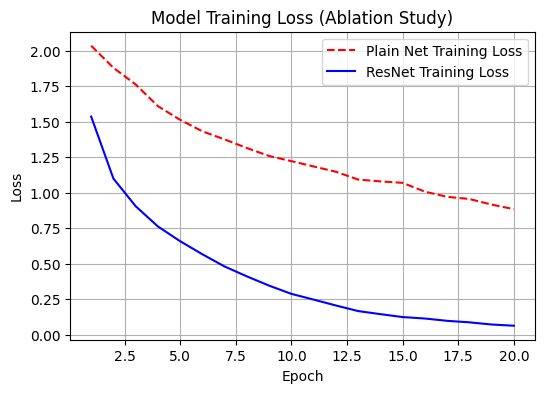

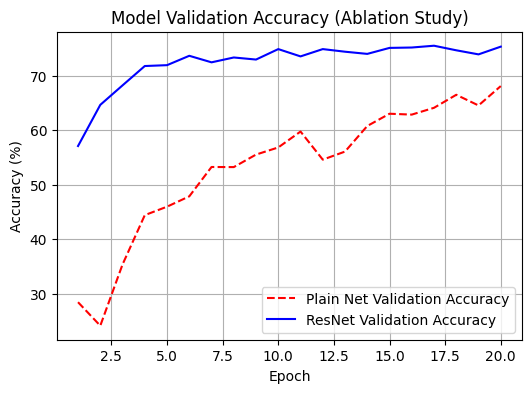

In [69]:
import os
import time
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
import matplotlib.pyplot as plt

# ----------------------------------------------------
# 1. 데이터 로드 세팅 (제공해주신 코드 반영)
# ----------------------------------------------------
base_path = os.path.join(os.getcwd(), '..', '..', 'work')
data_path = os.path.join(base_path, 'data')

transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))
])

trainset = torchvision.datasets.CIFAR10(root=data_path, train=True, download=True, transform=transform)
testset = torchvision.datasets.CIFAR10(root=data_path, train=False, download=True, transform=transform)

# 기존에 256이었던 배치 사이즈를 데이터 로더 기준(32)으로 자동 연동합니다.
trainloader = torch.utils.data.DataLoader(trainset, batch_size=32, shuffle=True)
testloader = torch.utils.data.DataLoader(testset, batch_size=32, shuffle=False)

EPOCH = 20
num_classes = 10  # CIFAR-10 클래스 수

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")


# ----------------------------------------------------
# 2. Plain Net 학습 (use_shortcut=False)
# ----------------------------------------------------
print("\n" + "="*50)
print("▶ Start Training: Plain Net (No Shortcut)")
print("="*50)

plain_net = ResNet(BasicBlock, [3, 4, 6, 3], num_classes=num_classes, use_shortcut=False)
plain_net.to(device)

criterion = nn.CrossEntropyLoss()
optimizer_plain = optim.SGD(plain_net.parameters(), lr=0.001, momentum=0.9, weight_decay=1e-4)

plain_train_losses = []
plain_val_accuracy = []

start_time = time.time()

for epoch in range(EPOCH):
    plain_net.train()
    running_loss = 0.0
    correct = 0
    total = 0

    for i, (inputs, labels) in enumerate(trainloader, 0):
        inputs, labels = inputs.to(device), labels.to(device)

        optimizer_plain.zero_grad()
        outputs = plain_net(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer_plain.step()

        running_loss += loss.item()
        _, predicted = torch.max(outputs, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()

        # 배치 사이즈가 32로 작아졌으므로, 300 배치마다 출력하도록 주기를 조정했습니다.
        if i % 300 == 299:
            print(f"[Epoch {epoch + 1}, Batch {i + 1:5d}] loss: {running_loss / (i + 1):.3f}")

    train_loss = running_loss / len(trainloader)
    plain_train_losses.append(train_loss)
    train_acc = 100 * correct / total
    print(f"Epoch {epoch + 1}: Plain Net Train Accuracy: {train_acc:.2f}%")

    # 검증 단계
    plain_net.eval()
    correct = 0
    total = 0
    with torch.no_grad():
        for inputs, labels in testloader:
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = plain_net(inputs)
            _, predicted = torch.max(outputs, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()

    val_acc = 100 * correct / total
    plain_val_accuracy.append(val_acc)
    print(f"Epoch {epoch + 1}: Plain Net Validation Accuracy: {val_acc:.2f}%\n")

plain_time = time.time() - start_time
print(f"Plain Net Training Finished. Time taken: {plain_time:.2f}s")


# ----------------------------------------------------
# 3. ResNet 학습 (use_shortcut=True)
# ----------------------------------------------------
print("\n" + "="*50)
print("▶ Start Training: ResNet (With Shortcut)")
print("="*50)

resnet = ResNet(BasicBlock, [3, 4, 6, 3], num_classes=num_classes, use_shortcut=True)
resnet.to(device)

optimizer_resnet = optim.SGD(resnet.parameters(), lr=0.001, momentum=0.9, weight_decay=1e-4)

resnet_train_losses = []
resnet_val_accuracy = []

start_time = time.time()

for epoch in range(EPOCH):
    resnet.train()
    running_loss = 0.0
    correct = 0
    total = 0

    for i, (inputs, labels) in enumerate(trainloader, 0):
        inputs, labels = inputs.to(device), labels.to(device)

        optimizer_resnet.zero_grad()
        outputs = resnet(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer_resnet.step()

        running_loss += loss.item()
        _, predicted = torch.max(outputs, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()

        if i % 300 == 299:
            print(f"[Epoch {epoch + 1}, Batch {i + 1:5d}] loss: {running_loss / (i + 1):.3f}")

    train_loss = running_loss / len(trainloader)
    resnet_train_losses.append(train_loss)
    train_acc = 100 * correct / total
    print(f"Epoch {epoch + 1}: ResNet Train Accuracy: {train_acc:.2f}%")

    # 검증 단계
    resnet.eval()
    correct = 0
    total = 0
    with torch.no_grad():
        for inputs, labels in testloader:
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = resnet(inputs)
            _, predicted = torch.max(outputs, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()

    val_acc = 100 * correct / total
    resnet_val_accuracy.append(val_acc)
    print(f"Epoch {epoch + 1}: ResNet Validation Accuracy: {val_acc:.2f}%\n")

resnet_time = time.time() - start_time
print(f"ResNet Training Finished. Time taken: {resnet_time:.2f}s")


# ----------------------------------------------------
# 4. 결과 시각화
# ----------------------------------------------------
epochs_range = range(1, EPOCH + 1)

# Loss 비교 그래프
plt.figure(figsize=(6, 4))
plt.plot(epochs_range, plain_train_losses, 'r--', label="Plain Net Training Loss")
plt.plot(epochs_range, resnet_train_losses, 'b-', label="ResNet Training Loss")
plt.title('Model Training Loss (Ablation Study)')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend(loc='upper right')
plt.grid(True)
plt.show()

# Accuracy 비교 그래프
plt.figure(figsize=(6, 4))
plt.plot(epochs_range, plain_val_accuracy, 'r--', label="Plain Net Validation Accuracy")
plt.plot(epochs_range, resnet_val_accuracy, 'b-', label="ResNet Validation Accuracy")
plt.title('Model Validation Accuracy (Ablation Study)')
plt.ylabel('Accuracy (%)')
plt.xlabel('Epoch')
plt.legend(loc='lower right')
plt.grid(True)
plt.show()

In [ ]:
회고:
ResNet의 핵심 아이디어인 shortcut에 대해 ablation study를 진행한 결과
같은 조건에서 shortcut을 적용한 케이스가 Train Loss, Validation Accurcy 모두 월등히 성능이 높았음을 확인할 수 있었음
